In [1360]:
from pathlib import Path
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

print("MNE version:", mne.__version__)


MNE version: 1.8.0


In [1361]:
# # for no b files
# data_path = r'H:\ASD projoect\ToM\ASD'

# data_name_a = r'3131a_CV.cnt'
# output_dir = os.path.join(data_path, data_name_a.replace('.cnt', '_processed_numpy'))
# os.makedirs(output_dir, exist_ok=True)

# files_a = sorted(glob.glob(os.path.join(data_path, data_name_a)))

# print("A files:")
# for f in files_a:
#     print(f)

# if len(files_a) == 0:
#     raise FileNotFoundError("3071a file not found")

# file_a = files_a[0]
# print(f"\nUsing file A: {file_a}")

# raw = mne.io.read_raw_cnt(
#     files_a[0],
#     preload=True
# )


In [1362]:
data_path = r'H:\ASD projoect\ToM\TD'

data_name_a = r'4210a_CV.cnt'
data_name_b = r'4210b_CV.cnt'

output_dir = os.path.join(data_path, data_name_a.replace('.cnt', '_processed_numpy'))
os.makedirs(output_dir, exist_ok=True)

files_a = sorted(glob.glob(os.path.join(data_path, data_name_a)))
files_b = sorted(glob.glob(os.path.join(data_path, data_name_b)))

print("A files:")
for f in files_a:
    print(f)

print("\nB files:")
for f in files_b:
    print(f)
    
if len(files_a) == 0:
    raise FileNotFoundError("a file not found")

if len(files_b) == 0:
    raise FileNotFoundError("b file not found")

file_a = files_a[0]
file_b = files_b[0]
print(f"\nUsing file A: {file_a}")
print(f"Using file B: {file_b}")

A files:
H:\ASD projoect\ToM\TD\4210a_CV.cnt

B files:
H:\ASD projoect\ToM\TD\4210b_CV.cnt

Using file A: H:\ASD projoect\ToM\TD\4210a_CV.cnt
Using file B: H:\ASD projoect\ToM\TD\4210b_CV.cnt


In [1363]:
raw_a = mne.io.read_raw_cnt(
    files_a[0],
    preload=True
)

raw_b = mne.io.read_raw_cnt(
    files_b[0],
    preload=True
)

print(raw_a)
print(raw_b)

Reading 0 ... 1859199  =      0.000 ...  1859.199 secs...


C:\Users\jzwht\AppData\Local\Temp\ipykernel_24796\3387918174.py:1: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw_a = mne.io.read_raw_cnt(


Reading 0 ... 1653499  =      0.000 ...  1653.499 secs...


C:\Users\jzwht\AppData\Local\Temp\ipykernel_24796\3387918174.py:6: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw_b = mne.io.read_raw_cnt(


<RawCNT | 4210a_CV.cnt, 65 x 1859200 (1859.2 s), ~922.1 MB, data loaded>
<RawCNT | 4210b_CV.cnt, 65 x 1653500 (1653.5 s), ~820.1 MB, data loaded>


In [1364]:
print("A sfreq:", raw_a.info["sfreq"])
print("B sfreq:", raw_b.info["sfreq"])

print("A channels:", len(raw_a.ch_names))
print("B channels:", len(raw_b.ch_names))

print("Same channel order:",
      raw_a.ch_names == raw_b.ch_names)

A sfreq: 1000.0
B sfreq: 1000.0
A channels: 65
B channels: 65
Same channel order: True


In [1365]:
raw = mne.concatenate_raws([
    raw_a,
    raw_b
])

print(raw)
print("Combined duration:", raw.times[-1], "seconds")

<RawCNT | 4210a_CV.cnt, 65 x 3512700 (3512.7 s), ~1.70 GB, data loaded>
Combined duration: 3512.699 seconds


In [1366]:
print(raw.ch_names)
print("Sampling rate:", raw.info["sfreq"])

descriptions = np.array(raw.annotations.description)

unique_desc, counts = np.unique(
    descriptions,
    return_counts=True
)

annotation_table = pd.DataFrame({
    "annotation": unique_desc,
    "count": counts
})

display(annotation_table)

['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'O1', 'OZ', 'O2', 'HEO', 'VEO', 'Trigger']
Sampling rate: 1000.0


,annotation,count
0,101,157
1,131,20
2,132,20
3,171,22
4,172,22
5,255,4
6,31,21
7,32,22
8,4,164
9,5,170


In [1367]:
for i in range(min(100, len(raw.annotations))):

    onset = raw.annotations.onset[i]
    desc = raw.annotations.description[i]

    print(
        f"{i:03d} | "
        f"{onset:10.3f} s | "
        f"{desc}"
    )

000 |     29.999 s | 255
001 |     30.000 s | 255
002 |     42.451 s | 91
003 |     46.467 s | 92
004 |     49.395 s | 93
005 |     52.083 s | 94
006 |     58.163 s | 99
007 |     58.700 s | 5
008 |     60.600 s | 71
009 |     65.602 s | 4
010 |     69.636 s | 101
011 |     70.184 s | 5
012 |     71.983 s | 31
013 |     76.985 s | 4
014 |     80.836 s | 101
015 |     85.700 s | 99
016 |     86.233 s | 5
017 |     88.032 s | 72
018 |     94.535 s | 4
019 |     99.108 s | 101
020 |     99.650 s | 5
021 |    101.449 s | 32
022 |    107.952 s | 4
023 |    112.244 s | 101
024 |    229.013 s | 91
025 |    234.421 s | 92
026 |    237.381 s | 93
027 |    240.085 s | 94
028 |    243.797 s | 99
029 |    244.335 s | 5
030 |    246.234 s | 31
031 |    251.236 s | 4
032 |    255.333 s | 101
033 |    255.868 s | 5
034 |    257.667 s | 71
035 |    262.670 s | 4
036 |    266.709 s | 101
037 |    269.925 s | 99
038 |    270.468 s | 5
039 |    272.267 s | 32
040 |    278.770 s | 4
041 |    283.381 s | 1

31 - cognitive first-order false
71 - affective first-order false
131 - cognitive first-order true
171 - affective first-order true

32 - cognitive second-order false
72 - affective second-order false
132 - cognitive second-order true
172 - affective second-order true

In [1368]:
tom_markers = {
    31:  {"tom": "cognitive", "order": "first",  "belief": "false"},
    71:  {"tom": "affective", "order": "first",  "belief": "false"},
    131: {"tom": "cognitive", "order": "first",  "belief": "true"},
    171: {"tom": "affective", "order": "first",  "belief": "true"},

    32:  {"tom": "cognitive", "order": "second", "belief": "false"},
    72:  {"tom": "affective", "order": "second", "belief": "false"},
    132: {"tom": "cognitive", "order": "second", "belief": "true"},
    172: {"tom": "affective", "order": "second", "belief": "true"},
}

audio_end = 4

outcome_map = {
    101: {"outcome": "correct", "correct": True},
    69:  {"outcome": "wrong",   "correct": False},
}


In [1369]:
all_codes = list(tom_markers.keys()) + [4] + list(outcome_map.keys())

event_id_true = {
    str(code): code
    for code in all_codes
}

events, event_id = mne.events_from_annotations(
    raw,
    event_id=event_id_true
)

print(event_id)

Used Annotations descriptions: ['101', '131', '132', '171', '172', '31', '32', '4', '69', '71', '72']
{'101': 101, '131': 131, '132': 132, '171': 171, '172': 172, '31': 31, '32': 32, '4': 4, '69': 69, '71': 71, '72': 72}


In [1370]:
trials = []

for i, event in enumerate(events):

    start_sample = event[0]
    code = event[2]

    if code not in tom_markers:
        continue

    audio_end_sample = None
    outcome_sample = None
    outcome_code = None

    # search forward
    for j in range(i + 1, len(events)):

        next_sample = events[j, 0]
        next_code = events[j, 2]

        # audio ends
        if next_code == 4 and audio_end_sample is None:
            audio_end_sample = next_sample

        # response outcome
        elif next_code in [101, 69] and audio_end_sample is not None:
            outcome_sample = next_sample
            outcome_code = next_code
            break

        # next question starts before outcome -> something is wrong
        elif next_code in tom_markers:
            break

    info = tom_markers[code]

    trials.append({
        "start_sample": start_sample,
        "audio_end_sample": audio_end_sample,
        "outcome_sample": outcome_sample,

        "trigger": code,
        "tom": info["tom"],
        "order": info["order"],
        "belief": info["belief"],

        "outcome_code": outcome_code,
        "correct": (
            outcome_code == 101
            if outcome_code is not None
            else np.nan
        ),

        "audio_duration_s": (
            (audio_end_sample - start_sample) / raw.info["sfreq"]
            if audio_end_sample is not None
            else np.nan
        ),

        "response_time_s": (
            (outcome_sample - audio_end_sample) / raw.info["sfreq"]
            if outcome_sample is not None
            and audio_end_sample is not None
            else np.nan
        )
    })

trial_df = pd.DataFrame(trials)

In [1371]:
display(trial_df.head(20))
print("Total trials:", len(trial_df))

,start_sample,audio_end_sample,outcome_sample,trigger,tom,order,belief,outcome_code,correct,audio_duration_s,response_time_s
0,60600,65602.0,69636.0,71,affective,first,false,101.0,True,5.002,4.034
1,71983,76985.0,80836.0,31,cognitive,first,false,101.0,True,5.002,3.851
2,88032,94535.0,99108.0,72,affective,second,false,101.0,True,6.503,4.573
3,101449,107952.0,112244.0,32,cognitive,second,false,101.0,True,6.503,4.292
4,246234,251236.0,255333.0,31,cognitive,first,false,101.0,True,5.002,4.097
5,257667,262670.0,266709.0,71,affective,first,false,101.0,True,5.003,4.039
6,272267,278770.0,283381.0,32,cognitive,second,false,101.0,True,6.503,4.611
7,285717,292220.0,296565.0,72,affective,second,false,101.0,True,6.503,4.345
8,318517,323520.0,327558.0,131,cognitive,first,true,101.0,True,5.003,4.038
9,329900,334903.0,338678.0,171,affective,first,true,101.0,True,5.003,3.775


Total trials: 169


In [1372]:
trial_df = trial_df.dropna(
    subset=["audio_end_sample", "outcome_sample", "outcome_code"]
).reset_index(drop=True)

print("Remaining complete trials:", len(trial_df))

trial_df = trial_df[
    trial_df["correct"] == True
].reset_index(drop=True)

print("Correct trials:", len(trial_df))

Remaining complete trials: 164
Correct trials: 157


In [1373]:
raw_proc = raw.copy()

raw_proc.set_channel_types({
    "HEO": "eog",
    "VEO": "eog",
    "Trigger": "misc"
})

raw_proc.filter(
    0.1,
    60,
    picks=["eeg", "eog"],
    method="iir",
    iir_params=dict(
        order=4,
        ftype="butter"
    )
)

print(raw_proc)

Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 0.1 - 60 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.10, 60.00 Hz: -6.02, -6.02 dB



C:\Users\jzwht\AppData\Local\Temp\ipykernel_24796\239009024.py:3: RuntimeWarning: The unit for channel(s) Trigger has changed from V to NA.
  raw_proc.set_channel_types({


<RawCNT | 4210a_CV.cnt, 65 x 3512700 (3512.7 s), ~1.70 GB, data loaded>


In [1374]:
sfreq = raw_proc.info["sfreq"]

n_pre = int(0.2 * sfreq)
n_post = int(2.5 * sfreq)

hearing_eeg = []
thinking_eeg = []

for _, row in trial_df.iterrows():

    q_start = int(row.start_sample)
    audio_end = int(row.audio_end_sample)

    # ------------------
    # Hearing
    # -0.2 -> +2.5 s
    # ------------------
    start = q_start - n_pre
    stop = q_start + n_post + 1

    x = raw_proc.get_data(
        start=start,
        stop=stop
    )

    x = x - x[:, :n_pre].mean(
        axis=1,
        keepdims=True
    )

    hearing_eeg.append(x)

    # ------------------
    # Thinking
    # -0.2 -> +2.5 s
    # ------------------
    start = audio_end - n_pre
    stop = audio_end + n_post + 1

    x = raw_proc.get_data(
        start=start,
        stop=stop
    )

    x = x - x[:, :n_pre].mean(
        axis=1,
        keepdims=True
    )

    thinking_eeg.append(x)

hearing_eeg = np.stack(hearing_eeg)
thinking_eeg = np.stack(thinking_eeg)

times = (
    np.arange(hearing_eeg.shape[2]) / sfreq
    - 0.2
)

print("Hearing:", hearing_eeg.shape)
print("Thinking:", thinking_eeg.shape)

Hearing: (157, 65, 2701)
Thinking: (157, 65, 2701)


In [1375]:
common_info = {
    "times": times,
    "channels": np.array(raw_proc.ch_names),
    "sfreq": sfreq,
    "metadata": trial_df.to_dict("list")
}

hearing_data = {
    "eeg": hearing_eeg,
    **common_info
}

thinking_data = {
    "eeg": thinking_eeg,
    **common_info
}

np.save(
    os.path.join(output_dir, "filtered_hearing_epoch.npy"),
    hearing_data,
    allow_pickle=True
)

np.save(
    os.path.join(output_dir, "filtered_thinking_epoch.npy"),
    thinking_data,
    allow_pickle=True
)

print("Saved filtered hearing and thinking epochs.")

Saved filtered hearing and thinking epochs.


In [1376]:
hearing = np.load(
    os.path.join(output_dir, "filtered_hearing_epoch.npy"),
    allow_pickle=True
).item()

thinking = np.load(
    os.path.join(output_dir, "filtered_thinking_epoch.npy"),
    allow_pickle=True
).item()

print(hearing["eeg"].shape)
print(thinking["eeg"].shape)

(157, 65, 2701)
(157, 65, 2701)


In [1377]:

def make_epochs(data):

    channels = list(data["channels"])

    ch_types = [
        "eog" if ch in ["HEO", "VEO"]
        else "misc" if ch == "Trigger"
        else "eeg"
        for ch in channels
    ]

    info = mne.create_info(
        channels,
        data["sfreq"],
        ch_types=ch_types
    )

    return mne.EpochsArray(
        data["eeg"],
        info,
        tmin=data["times"][0],
        metadata=pd.DataFrame(data["metadata"])
    )

hearing_epochs = make_epochs(hearing)
thinking_epochs = make_epochs(thinking)

Adding metadata with 11 columns
157 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 11 columns
157 matching events found
No baseline correction applied
0 projection items activated


In [1378]:
from mne.preprocessing import ICA

def run_ica(input_file, output_file):

    # --------------------------------------------------
    # 1. Load filtered epochs
    # --------------------------------------------------
    data = np.load(
        os.path.join(output_dir, input_file),
        allow_pickle=True
    ).item()

    print("Loaded:", input_file)
    print("EEG shape:", data["eeg"].shape)

    channels = list(data["channels"])

    # --------------------------------------------------
    # 2. Define channel types
    # --------------------------------------------------
    ch_types = []

    for ch in channels:

        if ch in ["HEO", "VEO"]:
            ch_types.append("eog")

        elif ch == "Trigger":
            ch_types.append("misc")

        else:
            ch_types.append("eeg")

    info = mne.create_info(
        ch_names=channels,
        sfreq=data["sfreq"],
        ch_types=ch_types
    )

    # --------------------------------------------------
    # 3. Reconstruct epochs
    # --------------------------------------------------
    epochs = mne.EpochsArray(
        data["eeg"],
        info,
        tmin=data["times"][0],
        metadata=pd.DataFrame(data["metadata"])
    )

    # --------------------------------------------------
    # 4. Add electrode locations
    #    needed for ICA topography + later interpolation
    # --------------------------------------------------
    montage = mne.channels.make_standard_montage(
        "standard_1020"
    )

    epochs.set_montage(
        montage,
        match_case=False,
        on_missing="ignore"
    )

    # --------------------------------------------------
    # 5. Fit ICA
    # --------------------------------------------------
    ica = ICA(
        n_components=0.99,
        random_state=42,
        max_iter="auto"
    )

    ica.fit(
        epochs,
        picks="eeg"
    )

    print("\nICA fitted:")
    print(ica)

    # --------------------------------------------------
    # 6. Automatically detect HEO/VEO artifacts
    # --------------------------------------------------
    heog_idx = []
    veog_idx = []

    if "HEO" in epochs.ch_names:
        heog_idx, _ = ica.find_bads_eog(
            epochs,
            ch_name="HEO"
        )

    if "VEO" in epochs.ch_names:
        veog_idx, _ = ica.find_bads_eog(
            epochs,
            ch_name="VEO"
        )

    ica.exclude = sorted(
        set(heog_idx + veog_idx)
    )

    print("\nHEO components:", heog_idx)
    print("VEO components:", veog_idx)
    print("Components removed:", ica.exclude)

    # --------------------------------------------------
    # 7. Plot components being removed
    # --------------------------------------------------
    if len(ica.exclude) > 0:

        ica.plot_components(
            picks=ica.exclude
        )

        ica.plot_properties(
            epochs,
            picks=ica.exclude
        )

    else:
        print("No EOG-related ICA components detected.")

    # --------------------------------------------------
    # 8. Apply ICA
    # --------------------------------------------------
    epochs_ica = epochs.copy()

    ica.apply(
        epochs_ica
    )

    # --------------------------------------------------
    # 9. Drop HEO, VEO, Trigger
    # --------------------------------------------------
    drop_channels = [
        ch for ch in ["HEO", "VEO", "Trigger"]
        if ch in epochs_ica.ch_names
    ]

    epochs_ica.drop_channels(
        drop_channels
    )

    # --------------------------------------------------
    # 10. Save ICA-cleaned data
    # --------------------------------------------------
    result = {
        "eeg": epochs_ica.get_data(),
        "times": epochs_ica.times,
        "channels": np.array(
            epochs_ica.ch_names
        ),
        "sfreq": epochs_ica.info["sfreq"],
        "metadata": epochs_ica.metadata.to_dict("list"),

        # keep ICA information
        "ica_exclude": np.array(
            ica.exclude
        ),
        "heog_components": np.array(
            heog_idx
        ),
        "veog_components": np.array(
            veog_idx
        ),
    }

    np.save(
        os.path.join(output_dir, output_file),
        result,
        allow_pickle=True
    )

    print("\nSaved:", os.path.join(output_dir, output_file))
    print("Final EEG shape:", result["eeg"].shape)

    return epochs_ica, ica

Loaded: filtered_hearing_epoch.npy
EEG shape: (157, 65, 2701)
Adding metadata with 11 columns
157 matching events found
No baseline correction applied
0 projection items activated
Fitting ICA to data using 62 channels (please be patient, this may take a while)


C:\Users\jzwht\AppData\Local\Temp\ipykernel_24796\493591271.py:73: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(


Selecting by explained variance: 32 components
Fitting ICA took 23.9s.

ICA fitted:
<ICA | epochs decomposition, method: fastica (fit in 80 iterations on 424057 samples), 32 ICA components (62 PCA components available), channel types: eeg, no sources marked for exclusion>
Using EOG channel: HEO
Using EOG channel: VEO

HEO components: [9, 0]
VEO components: [0]
Components removed: [0, 9]


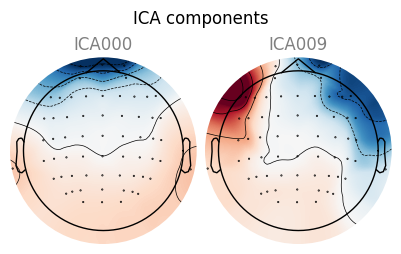

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
157 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
157 matching events found
No baseline correction applied
0 projection items activated


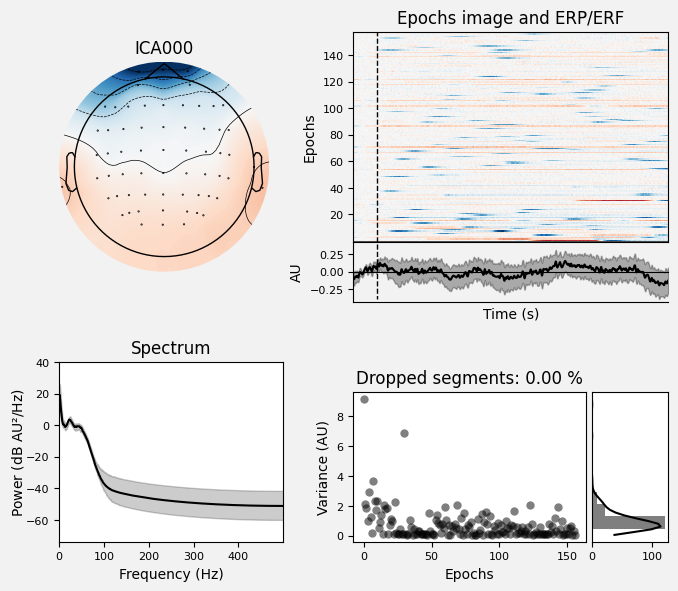

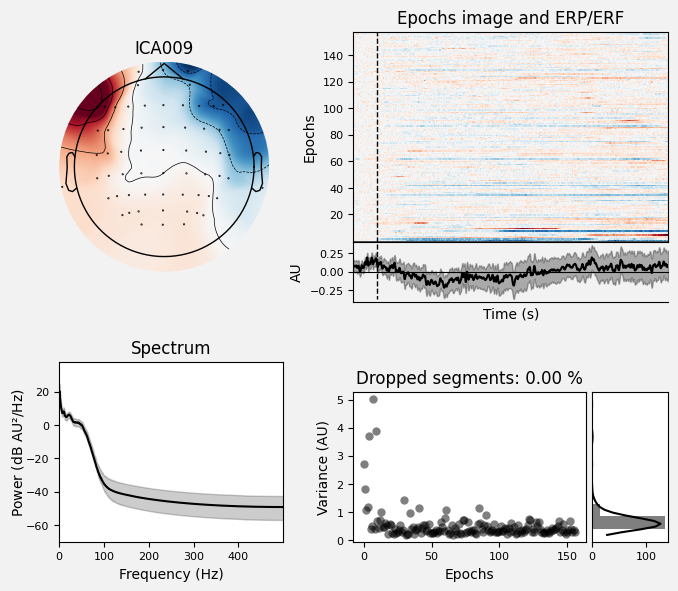

Applying ICA to Epochs instance
    Transforming to ICA space (32 components)
    Zeroing out 2 ICA components
    Projecting back using 62 PCA components

Saved: H:\ASD projoect\ToM\TD\4210a_CV_processed_numpy\ica_hearing_epoch.npy
Final EEG shape: (157, 62, 2701)


In [1379]:
hearing_ica, hearing_ica_model = run_ica(
    "filtered_hearing_epoch.npy",
    "ica_hearing_epoch.npy"
)

Loaded: filtered_thinking_epoch.npy
EEG shape: (157, 65, 2701)
Adding metadata with 11 columns
157 matching events found
No baseline correction applied
0 projection items activated
Fitting ICA to data using 62 channels (please be patient, this may take a while)


C:\Users\jzwht\AppData\Local\Temp\ipykernel_24796\493591271.py:73: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(


Selecting by explained variance: 23 components
Fitting ICA took 18.5s.

ICA fitted:
<ICA | epochs decomposition, method: fastica (fit in 81 iterations on 424057 samples), 23 ICA components (62 PCA components available), channel types: eeg, no sources marked for exclusion>
Using EOG channel: HEO
Using EOG channel: VEO

HEO components: [13, 3]
VEO components: [3, 13]
Components removed: [3, 13]


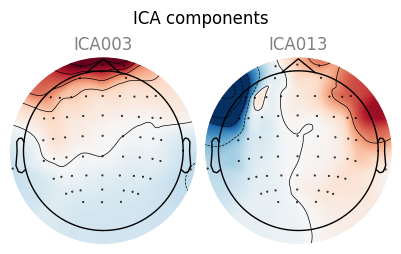

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
157 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
157 matching events found
No baseline correction applied
0 projection items activated


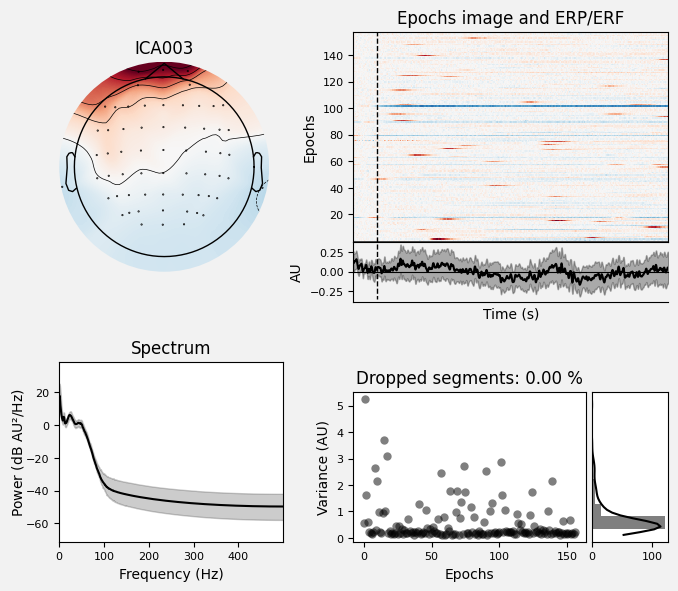

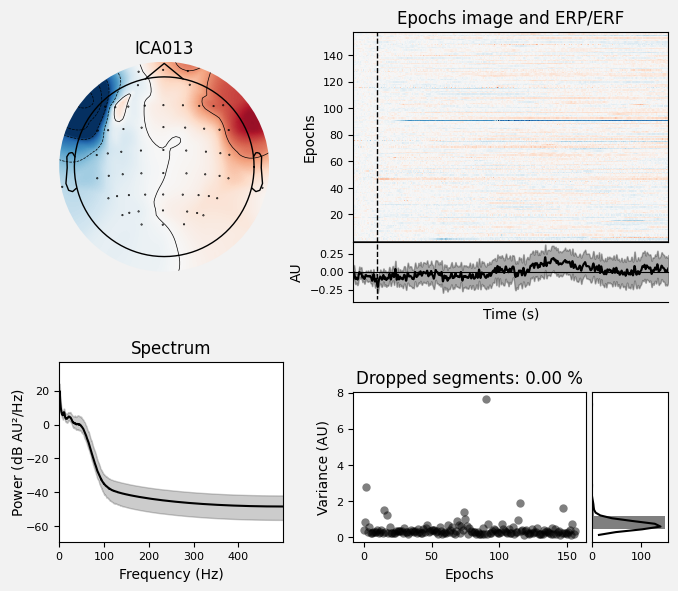

Applying ICA to Epochs instance
    Transforming to ICA space (23 components)
    Zeroing out 2 ICA components
    Projecting back using 62 PCA components

Saved: H:\ASD projoect\ToM\TD\4210a_CV_processed_numpy\ica_thinking_epoch.npy
Final EEG shape: (157, 62, 2701)


In [1380]:
thinking_ica, thinking_ica_model = run_ica(
    "filtered_thinking_epoch.npy",
    "ica_thinking_epoch.npy"
)

In [1381]:

hearing = np.load(
    os.path.join(output_dir, "ica_hearing_epoch.npy"),
    allow_pickle=True
).item()

thinking = np.load(
    os.path.join(output_dir, "ica_thinking_epoch.npy"),
    allow_pickle=True
).item()

print("Hearing:", hearing["eeg"].shape)
print("Thinking:", thinking["eeg"].shape)
print(hearing.keys())

Hearing: (157, 62, 2701)
Thinking: (157, 62, 2701)
dict_keys(['eeg', 'times', 'channels', 'sfreq', 'metadata', 'ica_exclude', 'heog_components', 'veog_components'])


In [1382]:
def interpolate_bad_channels(data, max_bad=20, bad_ratio=0.01):

    eeg = data["eeg"]
    channels = list(data["channels"])
    sfreq = data["sfreq"]

    info = mne.create_info(
        channels,
        sfreq,
        ch_types="eeg"
    )

    montage = mne.channels.make_standard_montage(
        "standard_1020"
    )

    info.set_montage(
        montage,
        match_case=False,
        on_missing="ignore"
    )

    cleaned = []
    good_idx = []
    bad_channels_record = []

    for i, x in enumerate(eeg):

        abs_x = np.abs(x)

        threshold = (
            abs_x.mean(axis=1)
            + 3 * abs_x.std(axis=1)
        )

        # number of samples exceeding threshold
        exceed = (
            abs_x
            > threshold[:, None]
        )

        # proportion of abnormal samples per channel
        exceed_ratio = exceed.mean(axis=1)

        # bad channel only if >1% samples are abnormal
        bad_mask = exceed_ratio > bad_ratio

        bad_chs = [
            ch
            for ch, bad in zip(channels, bad_mask)
            if bad
        ]

        # >20 bad channels -> reject epoch
        if len(bad_chs) > max_bad:
            continue

        epoch = mne.EpochsArray(
            x[np.newaxis, :, :],
            info.copy(),
            tmin=data["times"][0],
            verbose=False
        )

        if bad_chs:
            epoch.info["bads"] = bad_chs

            epoch.interpolate_bads(
                reset_bads=True,
                verbose=False
            )

        cleaned.append(
            epoch.get_data()[0]
        )

        good_idx.append(i)
        bad_channels_record.append(bad_chs)

    cleaned = np.stack(cleaned)

    return cleaned, good_idx, bad_channels_record

In [1383]:
hearing_cleaned, hearing_good_idx, hearing_bad_chs = interpolate_bad_channels(
    hearing,
    max_bad=20,
    bad_ratio=0.01
)

print("Original hearing epochs:", len(hearing["eeg"]))
print("Remaining:", len(hearing_cleaned))
print("Rejected:",
      len(hearing["eeg"]) - len(hearing_cleaned))

Original hearing epochs: 157
Remaining: 84
Rejected: 73


In [1384]:
thinking_cleaned, thinking_good_idx, thinking_bad_chs = (
    interpolate_bad_channels(
        thinking,
        max_bad=20,
        bad_ratio=0.01
    )
)

print("Original:", len(thinking["eeg"]))
print("Remaining:", len(thinking_cleaned))
print("Rejected:",
      len(thinking["eeg"]) - len(thinking_cleaned))

Original: 157
Remaining: 87
Rejected: 70


In [1385]:
print("Thinking bad channels per epoch:")
print([len(x) for x in thinking_bad_chs[:20]])

print("Hearing bad channels per epoch:")
print([len(x) for x in hearing_bad_chs[:20]])

Thinking bad channels per epoch:
[11, 8, 8, 14, 17, 7, 14, 13, 16, 12, 17, 9, 5, 14, 12, 19, 20, 4, 15, 19]
Hearing bad channels per epoch:
[13, 10, 5, 16, 17, 12, 17, 8, 9, 18, 13, 17, 14, 15, 13, 17, 3, 20, 18, 9]


In [1386]:
# Hearing
hearing_metadata = pd.DataFrame(hearing["metadata"])

hearing_final = {
    "eeg": hearing_cleaned,
    "times": hearing["times"],
    "channels": hearing["channels"],
    "sfreq": hearing["sfreq"],

    "metadata": hearing_metadata.iloc[
        hearing_good_idx
    ].reset_index(drop=True).to_dict("list"),

    "bad_channels": np.array(
        hearing_bad_chs,
        dtype=object
    ),

    "original_epoch_idx": np.array(
        hearing_good_idx
    )
}

np.save(
    os.path.join(output_dir, "interpolated_hearing_epoch.npy"),
    hearing_final,
    allow_pickle=True
)

print("Saved hearing:", hearing_cleaned.shape)

Saved hearing: (84, 62, 2701)


In [1387]:
# Thinking
thinking_metadata = pd.DataFrame(thinking["metadata"])

thinking_final = {
    "eeg": thinking_cleaned,
    "times": thinking["times"],
    "channels": thinking["channels"],
    "sfreq": thinking["sfreq"],

    "metadata": thinking_metadata.iloc[
        thinking_good_idx
    ].reset_index(drop=True).to_dict("list"),

    "bad_channels": np.array(
        thinking_bad_chs,
        dtype=object
    ),

    "original_epoch_idx": np.array(
        thinking_good_idx
    )
}

np.save(
    os.path.join(output_dir, "interpolated_thinking_epoch.npy"),
    thinking_final,
    allow_pickle=True
)

print("Saved thinking:", thinking_cleaned.shape)

Saved thinking: (87, 62, 2701)


In [1388]:
import numpy as np
import pandas as pd
import mne

data = np.load(
    os.path.join(output_dir, "interpolated_hearing_epoch.npy"),
    allow_pickle=True
).item()

metadata = pd.DataFrame(data["metadata"])

print("EEG:", data["eeg"].shape)
print("Time:", data["times"][0], "to", data["times"][-1])
print(metadata.head())

EEG: (84, 62, 2701)
Time: -0.2 to 2.5
   start_sample  audio_end_sample  outcome_sample  trigger        tom   order  \
0         60600           65602.0         69636.0       71  affective   first   
1        272267          278770.0        283381.0       32  cognitive  second   
2        285717          292220.0        296565.0       72  affective  second   
3        318517          323520.0        327558.0      131  cognitive   first   
4        329900          334903.0        338678.0      171  affective   first   

  belief  outcome_code  correct  audio_duration_s  response_time_s  
0  false         101.0     True             5.002            4.034  
1  false         101.0     True             6.503            4.611  
2  false         101.0     True             6.503            4.345  
3   true         101.0     True             5.003            4.038  
4   true         101.0     True             5.003            3.775  


In [1389]:
channels = list(data["channels"])

info = mne.create_info(
    ch_names=channels,
    sfreq=data["sfreq"],
    ch_types="eeg"
)

montage = mne.channels.make_standard_montage(
    "standard_1020"
)

info.set_montage(
    montage,
    match_case=False,
    on_missing="ignore"
)

epochs = mne.EpochsArray(
    data["eeg"],
    info,
    tmin=data["times"][0],
    metadata=metadata,
    verbose=False
)

print(epochs)

<EpochsArray | 84 events (all good), -0.2 – 2.5 s (baseline off), ~107.4 MB, data loaded, with metadata,
 '1': 84>


In [1390]:
epochs.set_eeg_reference(
    "average",
    projection=False
)

epochs.apply_baseline(
    baseline=(-0.2, 0)
)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Applying baseline correction (mode: mean)


<EpochsArray | 84 events (all good), -0.2 – 2.5 s (baseline -0.2 – 0 s), ~107.4 MB, data loaded, with metadata,
 '1': 84>

In [1391]:
conditions = {
    "false_cognitive":
        (metadata["belief"] == "false") &
        (metadata["tom"] == "cognitive"),

    "false_affective":
        (metadata["belief"] == "false") &
        (metadata["tom"] == "affective"),

    "true_cognitive":
        (metadata["belief"] == "true") &
        (metadata["tom"] == "cognitive"),

    "true_affective":
        (metadata["belief"] == "true") &
        (metadata["tom"] == "affective")
}

for name, mask in conditions.items():
    print(name, mask.sum())

false_cognitive 22
false_affective 21
true_cognitive 18
true_affective 23


In [1392]:
erp_defs = {
    "LPC": {
        "tmin": 0.300,
        "tmax": 0.600,
        "channels": [
            "FZ", "F1", "F2",
            "FCZ", "FC1", "FC2"
        ]
    },

    "early_LSW": {
        "tmin": 0.800,
        "tmax": 1.400,
        "channels": [
            "CPZ", "CP1", "CP2", "CP3", "CP4",
            "PZ", "P1", "P2", "P3", "P4",
            "POZ", "PO3", "PO4"
        ]
    },

    "mid_LSW": {
        "tmin": 1.400,
        "tmax": 2.100,
        "channels": [
            "CPZ", "CP1", "CP2", "CP3", "CP4",
            "PZ", "P1", "P2", "P3", "P4",
            "POZ", "PO3", "PO4"
        ]
    },

    "late_LSW": {
        "tmin": 2.000,
        "tmax": 2.500,
        "channels": [
            "CPZ", "CP1", "CP2", "CP3", "CP4",
            "PZ", "P1", "P2", "P3", "P4",
            "POZ", "PO3", "PO4"
        ]
    }
}

In [1393]:
results = []

for condition, mask in conditions.items():

    idx = np.where(mask.to_numpy())[0]

    for component, cfg in erp_defs.items():

        use_chs = [
            ch for ch in cfg["channels"]
            if ch in epochs.ch_names
        ]

        ep = (
            epochs[idx]
            .copy()
            .pick(use_chs)
            .crop(
                tmin=cfg["tmin"],
                tmax=cfg["tmax"]
            )
        )

        # trial × channel × time
        x = ep.get_data() * 1e6

        # average over channels and time
        trial_amp = x.mean(axis=(1, 2))

        for j, original_idx in enumerate(idx):

            results.append({
                "epoch_idx": original_idx,
                "condition": condition,
                "component": component,
                "amplitude_uV": trial_amp[j],

                "tom": metadata.iloc[original_idx]["tom"],
                "order": metadata.iloc[original_idx]["order"],
                "belief": metadata.iloc[original_idx]["belief"]
            })

erp_trial_results = pd.DataFrame(results)

erp_trial_results.head()

,epoch_idx,condition,component,amplitude_uV,tom,order,belief
0,1,false_cognitive,LPC,-1.872655,cognitive,second,false
1,9,false_cognitive,LPC,6.047513,cognitive,first,false
2,10,false_cognitive,LPC,3.189708,cognitive,second,false
3,15,false_cognitive,LPC,3.892718,cognitive,first,false
4,16,false_cognitive,LPC,9.925610,cognitive,second,false


In [1394]:
erp_summary = (
    erp_trial_results
    .groupby(
        ["condition", "component"]
    )["amplitude_uV"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

erp_summary

,condition,component,mean,std,count
0,false_affective,LPC,4.238724,8.706385,21
1,false_affective,early_LSW,0.657383,5.593858,21
2,false_affective,late_LSW,-0.487463,4.923446,21
3,false_affective,mid_LSW,-0.447433,4.326806,21
4,false_cognitive,LPC,1.362839,7.515429,22
5,false_cognitive,early_LSW,-2.155714,8.931126,22
6,false_cognitive,late_LSW,-3.903039,7.808124,22
7,false_cognitive,mid_LSW,-2.787293,7.110030,22
8,true_affective,LPC,3.633154,5.865335,23
9,true_affective,early_LSW,-0.202392,6.791923,23


In [1395]:
erp_trial_results.to_csv(
    os.path.join(output_dir, "ToM_hearing_ERP_trial_results.csv"),
    index=False
)

erp_summary.to_csv(
    os.path.join(output_dir, "ToM_hearing_ERP_summary.csv"),
    index=False
)

print("ERP results saved.")

ERP results saved.
